In [1]:

# ── Imports ────────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point, box
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from sklearn.cluster import DBSCAN


In [2]:

# ── Constants ──────────────────────────────────────────────────────────────────
ROOT = "../../"

# Input paths
PARCEL_SHP      = ROOT + "data/geo/Parcels_7711352183771741448/Parcel_Boundaries.shp"
BUSINESS_XLSX   = ROOT + "data/business/Oakland_DataAxleV2.xlsx"
OAKLAND_SHP     = ROOT + "data/geo/OaklandCityLimits/OaklandCityLimits.shp"

# Corridor shapefiles
OAK_BIDS_SHP        = ROOT + "data/corridors/OAK_BIDs/OAK_BIDs.shp"
POLICY_POLYGONS_SHP = ROOT + "data/corridors/Policy_Polygons/Policy_Polygons.shp"

# Output paths
OUT_DIR         = ROOT + "data/corridors/parcels/"
OUT_USE_CODE    = OUT_DIR + "parcels_use_code_filtered.gpkg"
OUT_BIZ_CONTAIN = OUT_DIR + "parcels_with_business.gpkg"
OUT_UNION       = OUT_DIR + "parcels_union.gpkg"

# Use code prefixes to keep (3xxx, 8xxx, 9xxx)
USE_CODE_PREFIXES = ("3", "8", "9")

# Coordinate reference systems
PARCEL_CRS   = "EPSG:3857"   # Web Mercator (native CRS of the parcel shapefile)
BUSINESS_CRS = "EPSG:4326"   # WGS 84 (lat/lon of the business data)
CORRIDOR_CRS = "EPSG:4269"   # NAD 83 (native CRS of the corridor shapefiles)

# ── Section 3 — corridor methodology parameters ────────────────────────────────

# Approach A: DBSCAN clustering of business points
# Within Oakland a single global run is appropriate — the city is small enough
# that sub-region stratification is not needed.
DBSCAN_EPS_M          = 150   # neighbourhood radius in metres (tighter for Oakland scale)
DBSCAN_MIN_SAMPLES    = 5     # minimum points to form a core point
DBSCAN_MIN_CLUSTER_N  = 10    # drop clusters with fewer businesses than this
DBSCAN_BIZ_BUFFER_M   = 60    # buffer around each point when building cluster footprint

# Approach B: Grid-density thresholding (global absolute threshold within Oakland)
GRID_CELL_SIZE_M      = 250   # fishnet cell width/height in metres (finer for Oakland)
GRID_BIZ_THRESHOLD    = 5     # minimum businesses per cell to be "active"
GRID_MIN_CELLS        = 2     # minimum cells in a dissolved blob to keep

# Approach C: Parcel-connectivity blobs + spatial-diversity selection
PARCEL_CONNECT_BUF_M  = 40    # buffer to bridge adjacent parcels before dissolve
BLOB_MIN_PARCELS      = 10    # minimum union parcels in a blob to keep (smaller for Oakland)
TARGET_CORRIDORS      = 15    # approximate number of corridors to select within Oakland
MIN_SPACING_M         = 1000  # minimum centroid-to-centroid distance between selections



# Section 1 — Identify Preliminary Corridor Parcels

This section filters the Oakland parcel dataset to produce three targeted parcel layers,
all saved as GeoPackage files under `data/corridors/parcels/`:

| Output file | Description |
|---|---|
| `parcels_use_code_filtered.gpkg` | Parcels within Oakland whose `UseCode` starts with 3, 8, or 9 (commercial / industrial / special use) |
| `parcels_with_business.gpkg` | Oakland parcels that contain at least one DataAxle business centroid |
| `parcels_union.gpkg` | Union of the two filtered sets (deduplicated) |



## 1.1 Load Parcel Data

Read the Alameda County parcel shapefile into a GeoDataFrame, then clip to the
**Oakland city limits** (`OaklandCityLimits.shp`).  
The native CRS is **EPSG:3857** (Web Mercator).


In [3]:

# Load full parcel shapefile (~1 GB on disk; reads into memory as a GeoDataFrame)
parcels = gpd.read_file(PARCEL_SHP)

# Load Oakland city limits and clip parcels to the city boundary.
# We filter by centroid to preserve whole parcel polygons.
oakland = gpd.read_file(OAKLAND_SHP).to_crs(PARCEL_CRS)
oakland_geom = oakland.unary_union
parcels = parcels[parcels.geometry.centroid.within(oakland_geom)].copy().reset_index(drop=True)

print(f"Total parcels loaded (Oakland only) : {len(parcels):,}")
print(f"CRS                                 : {parcels.crs}")
print(f"UseCode sample values               : {parcels['UseCode'].dropna().unique()[:10]}")


Total parcels loaded (Oakland only) : 113,036
CRS                                 : EPSG:3857
UseCode sample values               : ['1100' '3600' '0500' '0300' '8300' '4100' '4102' '2500' '3000' '4000']



## 1.2 Filter Parcels by Use Code (3xxx / 8xxx / 9xxx)

Retain only parcels whose 4-digit `UseCode` begins with **3** (commercial),
**8** (institutional / public), or **9** (miscellaneous / special).  
The result is saved to `parcels_use_code_filtered.gpkg`.


In [4]:

# Cast UseCode to string and normalise to 4 characters (zero-pad if needed),
# then keep rows whose first character matches one of the target prefixes.
parcels["UseCode_str"] = (
    parcels["UseCode"]
    .astype(str)
    .str.strip()
    .str.zfill(4)
)

mask_use_code = parcels["UseCode_str"].str[0].isin(list(USE_CODE_PREFIXES))
parcels_use_code = parcels[mask_use_code].copy()

print(f"Parcels matching 3xxx/8xxx/9xxx use codes : {len(parcels_use_code):,}")
print(parcels_use_code["UseCode_str"].value_counts().head(15))

# Save to GeoPackage
os.makedirs(OUT_DIR, exist_ok=True)
parcels_use_code.to_file(OUT_USE_CODE, driver="GPKG")
print(f"\nSaved → {OUT_USE_CODE}")


Parcels matching 3xxx/8xxx/9xxx use codes : 5,346
UseCode_str
3200    1186
3100     965
9400     411
3000     374
3900     349
8100     345
8300     304
3300     202
3600     194
9300     150
9401     130
8500     102
9901      87
9500      62
9000      48
Name: count, dtype: int64

Saved → ../../data/corridors/parcels/parcels_use_code_filtered.gpkg



## 1.3 Load Business Data and Build GeoDataFrame

Read the DataAxle business registry from the Excel file.  
`Latitude` / `Longitude` are in **WGS 84 (EPSG:4326)**, so we construct point
geometries, reproject to match the parcel CRS (**EPSG:3857**), and then clip to
the **Oakland city limits** before the spatial join.


In [5]:

# Load business registry (only need the coordinate columns for spatial work)
businesses_df = pd.read_excel(BUSINESS_XLSX)

# Drop rows that have no usable coordinates
businesses_df = businesses_df.dropna(subset=["Latitude", "Longitude"])

print(f"Businesses with valid coordinates : {len(businesses_df):,}")

# Build GeoDataFrame — points from lat/lon (WGS 84)
businesses_gdf = gpd.GeoDataFrame(
    businesses_df,
    geometry=gpd.points_from_xy(businesses_df["Longitude"], businesses_df["Latitude"]),
    crs=BUSINESS_CRS,
)

# Reproject to the same CRS as the parcel layer (EPSG:3857)
businesses_gdf = businesses_gdf.to_crs(PARCEL_CRS)

# Clip to Oakland city limits (oakland_geom defined in Section 1.1)
businesses_gdf = businesses_gdf[businesses_gdf.geometry.within(oakland_geom)].copy().reset_index(drop=True)

print(f"Business CRS after reprojection   : {businesses_gdf.crs}")
print(f"Businesses within Oakland         : {len(businesses_gdf):,}")


Businesses with valid coordinates : 29,545
Business CRS after reprojection   : EPSG:3857
Businesses within Oakland         : 29,370



## 1.4 Filter Parcels That Contain a Business Centroid

Use a spatial join (`predicate="contains"`) to find every parcel polygon that
contains at least one business point.  We then deduplicate by parcel index so
each parcel appears only once regardless of how many businesses it contains.  
The result is saved to `parcels_with_business.gpkg`.


In [6]:

# Spatial join: keep only parcel rows that contain ≥1 business point.
# how="inner" returns one row per (parcel, business) match — we deduplicate after.
joined = gpd.sjoin(
    parcels,                   # left  — polygon layer
    businesses_gdf[["geometry"]],  # right — point layer (geometry only to keep output slim)
    how="inner",
    predicate="contains",
)

# Deduplicate: one row per parcel (a parcel may match many businesses)
parcels_with_biz = parcels.loc[joined.index.unique()].copy()

print(f"Parcels containing ≥1 business centroid : {len(parcels_with_biz):,}")

# Save to GeoPackage
parcels_with_biz.to_file(OUT_BIZ_CONTAIN, driver="GPKG")
print(f"Saved → {OUT_BIZ_CONTAIN}")


Parcels containing ≥1 business centroid : 15,855
Saved → ../../data/corridors/parcels/parcels_with_business.gpkg



## 1.5 Build the Union Layer

Concatenate the two filtered parcel sets and drop duplicate rows (by original
DataFrame index) so that a parcel matching both criteria appears only once.  
The result is saved to `parcels_union.gpkg`.


In [7]:

# Combine the two filtered layers and deduplicate by original row index
parcels_union = (
    pd.concat([parcels_use_code, parcels_with_biz])
    .pipe(gpd.GeoDataFrame, crs=PARCEL_CRS)
    # Reset index to expose it as a column, drop duplicate original indices
    .reset_index(drop=False)
    .drop_duplicates(subset="index")
    .set_index("index")
)

print(f"Parcels in use-code filter   : {len(parcels_use_code):,}")
print(f"Parcels with business        : {len(parcels_with_biz):,}")
print(f"Parcels in union (no dups)   : {len(parcels_union):,}")

# Save to GeoPackage
parcels_union.to_file(OUT_UNION, driver="GPKG")
print(f"\nSaved → {OUT_UNION}")


Parcels in use-code filter   : 5,346
Parcels with business        : 15,855
Parcels in union (no dups)   : 18,365

Saved → ../../data/corridors/parcels/parcels_union.gpkg



# Section 2 — Corridor Coverage Analysis

The existing corridor definitions come from two sources:

| Layer | Description | Features |
|---|---|---|
| **OAK_BIDs** | Oakland Business Improvement Districts | 11 named BIDs |
| **Policy_Polygons** | Researcher-defined policy study areas | 9 named areas |

For each layer — individually and combined — we measure how well the corridor boundaries
capture the **three parcel filters** produced in Section 1:

* **Use-code parcels** — 3xxx / 8xxx / 9xxx
* **Business-containing parcels** — has ≥ 1 DataAxle business inside
* **Union parcels** — either of the above

Coverage is expressed as both **raw counts** and **% of each filtered set**.



## 2.1 Load and Reproject Corridor Layers

Both corridor shapefiles are in **EPSG:4269** (NAD 83).  We reproject them to
**EPSG:3857** to match the parcel layer before any spatial operations.  We also
build a single combined layer that is the union of both corridor geometries.


In [8]:

# Load corridor layers and reproject to match parcels (EPSG:3857)
oak_bids = gpd.read_file(OAK_BIDS_SHP).to_crs(PARCEL_CRS)
policy   = gpd.read_file(POLICY_POLYGONS_SHP).to_crs(PARCEL_CRS)

# Combined layer: dissolve both into a single multipolygon union
combined_geom = unary_union(
    oak_bids.geometry.tolist() + policy.geometry.tolist()
)
combined = gpd.GeoDataFrame(geometry=[combined_geom], crs=PARCEL_CRS)

print(f"OAK_BIDs   : {len(oak_bids)} corridors  | CRS: {oak_bids.crs}")
print(f"Policy     : {len(policy)} areas       | CRS: {policy.crs}")
print(f"OAK BID names   : {oak_bids['BID'].tolist()}")
print(f"Policy names    : {policy['PP_Name'].tolist()}")


OAK_BIDs   : 11 corridors  | CRS: EPSG:3857
Policy     : 9 areas       | CRS: EPSG:3857
OAK BID names   : ['Downtown', 'Chinatown', 'Lake Merritt', 'Koreatown/Northgate', 'Montclair', 'Rockridge', 'Temescal/Telegraph', 'Fruitvale', 'Lakeshore', 'Jack London', 'Laurel']
Policy names    : ['Seventh Thrives', 'West Oakland S', 'Little Saigon', 'Hegenberger_BID', 'Beat19x', 'Fruitvale_BID', 'Telegraph Triangle', 'Old_Oakland', 'Dimond']



## 2.2 Coverage Helper

A reusable function counts, for a given parcel set, how many parcel centroids
fall **within** a corridor layer.  Using centroids (rather than full polygon
intersection) avoids partial-overlap ambiguity and is fast even on large sets.


In [9]:

def count_covered(parcel_gdf: gpd.GeoDataFrame, corridor_gdf: gpd.GeoDataFrame) -> int:
    """Return the number of parcels whose centroid lies within any corridor polygon."""
    centroids = parcel_gdf.copy()
    centroids["geometry"] = parcel_gdf.geometry.centroid
    joined = gpd.sjoin(centroids[["geometry"]], corridor_gdf[["geometry"]], how="inner", predicate="within")
    return joined.index.nunique()


def coverage_stats(parcel_sets: dict, corridor_layers: dict) -> pd.DataFrame:
    """
    Build a tidy coverage table.

    Parameters
    ----------
    parcel_sets    : {label: GeoDataFrame}  — the filtered parcel layers
    corridor_layers: {label: GeoDataFrame}  — the corridor layers to test

    Returns
    -------
    DataFrame with columns: corridor, parcel_set, total, covered, pct_covered
    """
    rows = []
    for c_name, corridors in corridor_layers.items():
        for p_name, parcels in parcel_sets.items():
            total   = len(parcels)
            covered = count_covered(parcels, corridors)
            rows.append({
                "corridor"   : c_name,
                "parcel_set" : p_name,
                "total"      : total,
                "covered"    : covered,
                "pct_covered": round(covered / total * 100, 1) if total else 0.0,
            })
    return pd.DataFrame(rows)



## 2.3 Overall Coverage Summary Table

Run the coverage helper across all three parcel sets × three corridor configurations.


In [10]:

parcel_sets = {
    "Use-code (3/8/9xxx)" : parcels_use_code,
    "Has business"        : parcels_with_biz,
    "Union"               : parcels_union,
}

corridor_layers = {
    "OAK BIDs"   : oak_bids,
    "Policy"     : policy,
    "Combined"   : combined,
}

coverage_df = coverage_stats(parcel_sets, corridor_layers)

# Pivot for readability: corridors as rows, parcel sets as columns (% covered)
pivot_pct = coverage_df.pivot(index="corridor", columns="parcel_set", values="pct_covered")
pivot_n   = coverage_df.pivot(index="corridor", columns="parcel_set", values="covered")

print("=== Parcels covered (count) ===")
print(pivot_n.to_string())
print()
print("=== Parcels covered (%) ===")
print(pivot_pct.to_string())


=== Parcels covered (count) ===
parcel_set  Has business  Union  Use-code (3/8/9xxx)
corridor                                            
Combined            6079   6941                 2470
OAK BIDs            4355   4911                 1845
Policy              2154   2600                  967

=== Parcels covered (%) ===
parcel_set  Has business  Union  Use-code (3/8/9xxx)
corridor                                            
Combined            38.3   37.8                 46.2
OAK BIDs            27.5   26.7                 34.5
Policy              13.6   14.2                 18.1



## 2.4 Coverage Bar Chart — % of Each Parcel Set Captured

Grouped bar chart showing what share of each filtered parcel set is captured
by OAK BIDs, Policy Polygons, and their combination.


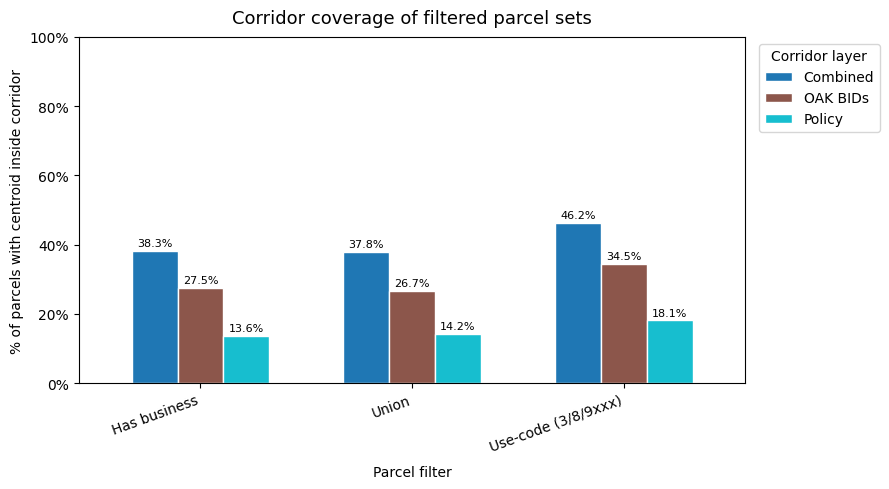

In [11]:

fig, ax = plt.subplots(figsize=(9, 5))

pivot_pct.T.plot(
    kind="bar",
    ax=ax,
    width=0.65,
    colormap="tab10",
    edgecolor="white",
)

ax.set_title("Corridor coverage of filtered parcel sets", fontsize=13, pad=10)
ax.set_xlabel("Parcel filter", labelpad=8)
ax.set_ylabel("% of parcels with centroid inside corridor")
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
ax.legend(title="Corridor layer", bbox_to_anchor=(1.01, 1), loc="upper left")
ax.set_ylim(0, 100)

# Annotate each bar with its value
for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", label_type="edge", fontsize=8, padding=2)

plt.tight_layout()
plt.show()



## 2.8 Spatial Map — Corridors vs. Union Parcels

A quick map to visualise which parts of the East Bay the corridor layers cover
relative to the full union parcel set.  Parcel centroids are plotted as grey
dots; corridor outlines are overlaid on top.


In [12]:

# Pre-compute union parcel centroids (used in map and Section 3)
union_centroids = parcels_union.copy()
union_centroids["geometry"] = parcels_union.geometry.centroid


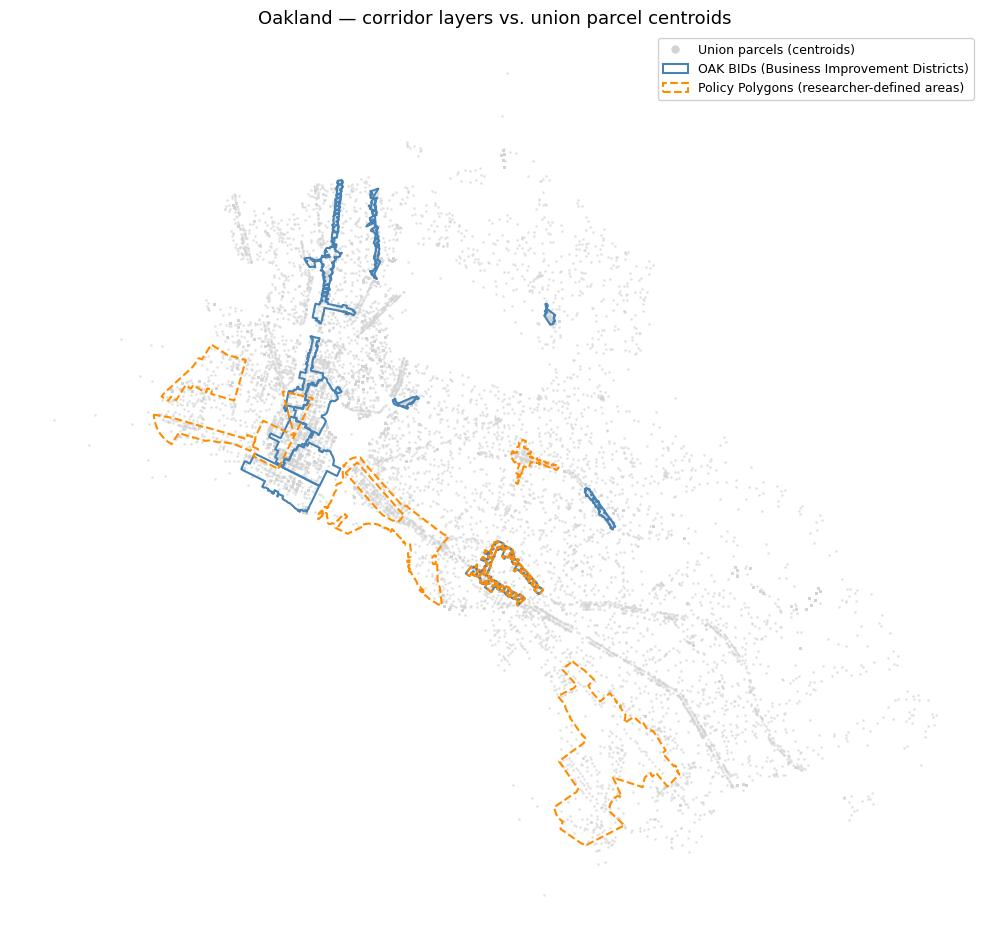

In [14]:

fig, ax = plt.subplots(figsize=(10, 10))

# Plot union parcel centroids as light grey dots
union_centroids.plot(ax=ax, color="lightgrey", markersize=1, alpha=0.5)

# OAK BIDs — solid blue outlines
oak_bids.plot(ax=ax, facecolor="none", edgecolor="steelblue", linewidth=1.5)

# Policy Polygons — dashed orange outlines
policy.plot(ax=ax, facecolor="none", edgecolor="darkorange", linewidth=1.5, linestyle="--")

legend_handles = [
    mlines.Line2D([], [], color="lightgrey", marker="o", linestyle="None",
                  markersize=5, label="Union parcels (centroids)"),
    mpatches.Patch(facecolor="none", edgecolor="steelblue", linewidth=1.5,
                   label="OAK BIDs (Business Improvement Districts)"),
    mpatches.Patch(facecolor="none", edgecolor="darkorange", linewidth=1.5,
                   linestyle="--", label="Policy Polygons (researcher-defined areas)"),
]

ax.set_title("Oakland — corridor layers vs. union parcel centroids", fontsize=13)
ax.legend(handles=legend_handles, loc="upper right", fontsize=9, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()
plt.show()



# Section 3 — Exploratory Corridor Methodology

The existing BID and Policy Polygon boundaries capture **< 40 %** of the filtered parcel set
(Section 2), which confirms that a more data-driven approach is needed.

This section explores three starter methodologies, each representing a different philosophical
frame for what a "corridor" is.  All three operate exclusively within the **City of Oakland**.
The guiding design goal is approximately **15 corridors distributed across Oakland**, not a
concentration in the highest-density downtown area alone.  Each approach is adapted to that target.

| # | Approach | Core idea |
|---|---|---|
| **3.1** | DBSCAN business clustering | A corridor is a *dense concentration of businesses* |
| **3.2** | Grid-density thresholding | A corridor is a *high-activity zone* on a regular grid |
| **3.3** | Parcel-connectivity blobs | A corridor is a *contiguous island of commercial land* |

None of these is a final answer.  The goal is to surface candidate geometries distributed
across Oakland that can seed a richer, participatory definition — one where geography,
community recognition, and economic activity are all balanced.



## 3.1 Approach A — DBSCAN Clustering of Business Locations

**Idea:** Run DBSCAN on business point coordinates to identify dense clusters.  Within Oakland,
a single global run is appropriate — the city (~77 km²) is compact and the business data is
centred here, so there is no need to stratify into sub-regions.  The full Oakland business
dataset is evaluated as one coherent area.

Each cluster's footprint is built as a union of small buffers around its member points,
producing an organic shape that conforms to street-level concentrations.

**Parameters:**

| Parameter | Value | Meaning |
|---|---|---|
| `eps` | 150 m | Neighbourhood radius — how close two businesses must be |
| `min_samples` | 5 | Minimum neighbours to form a core point |
| Point buffer | 60 m | Buffer applied per point to build the cluster footprint |
| Min cluster size | 10 businesses | Discard trivially small clusters |


In [15]:

# ── Global DBSCAN within Oakland ──────────────────────────────────────────────
# Oakland (~77 km²) is compact enough that a single global DBSCAN run is
# appropriate — there is no need to stratify into sub-regions because the
# city's commercial fabric is evaluated as one coherent area.

coords_all = np.column_stack([businesses_gdf.geometry.x, businesses_gdf.geometry.y])
db = DBSCAN(eps=DBSCAN_EPS_M, min_samples=DBSCAN_MIN_SAMPLES,
            algorithm="ball_tree", metric="euclidean").fit(coords_all)

businesses_gdf = businesses_gdf.copy()
businesses_gdf["_cluster"] = db.labels_

all_polys = []
for cid in sorted(set(db.labels_[db.labels_ >= 0])):
    pts = businesses_gdf[businesses_gdf["_cluster"] == cid]["geometry"]
    if len(pts) < DBSCAN_MIN_CLUSTER_N:
        continue
    footprint = unary_union([p.buffer(DBSCAN_BIZ_BUFFER_M) for p in pts])
    all_polys.append({"n_businesses": len(pts), "geometry": footprint})

dbscan_corridors = gpd.GeoDataFrame(all_polys, crs=PARCEL_CRS).reset_index(drop=True)

n_raw_clusters = len(set(db.labels_[db.labels_ >= 0]))
noise_frac     = (db.labels_ == -1).mean() * 100

print(f"DBSCAN results (eps={DBSCAN_EPS_M} m, min_samples={DBSCAN_MIN_SAMPLES}):")
print(f"  Total businesses              : {len(businesses_gdf):,}")
print(f"  Raw clusters found            : {n_raw_clusters}")
print(f"  Noise fraction                : {noise_frac:.1f}%")
print(f"  Corridors kept (≥{DBSCAN_MIN_CLUSTER_N} biz)    : {len(dbscan_corridors)}")
print(f"\nTop clusters by business count:")
print(dbscan_corridors.sort_values("n_businesses", ascending=False)
      [["n_businesses"]].head(12).to_string(index=False))


DBSCAN results (eps=150 m, min_samples=5):
  Total businesses              : 29,370
  Raw clusters found            : 247
  Noise fraction                : 5.7%
  Corridors kept (≥10 biz)    : 119

Top clusters by business count:
 n_businesses
        11853
         5460
          965
          875
          713
          646
          544
          406
          265
          240
          239
          234


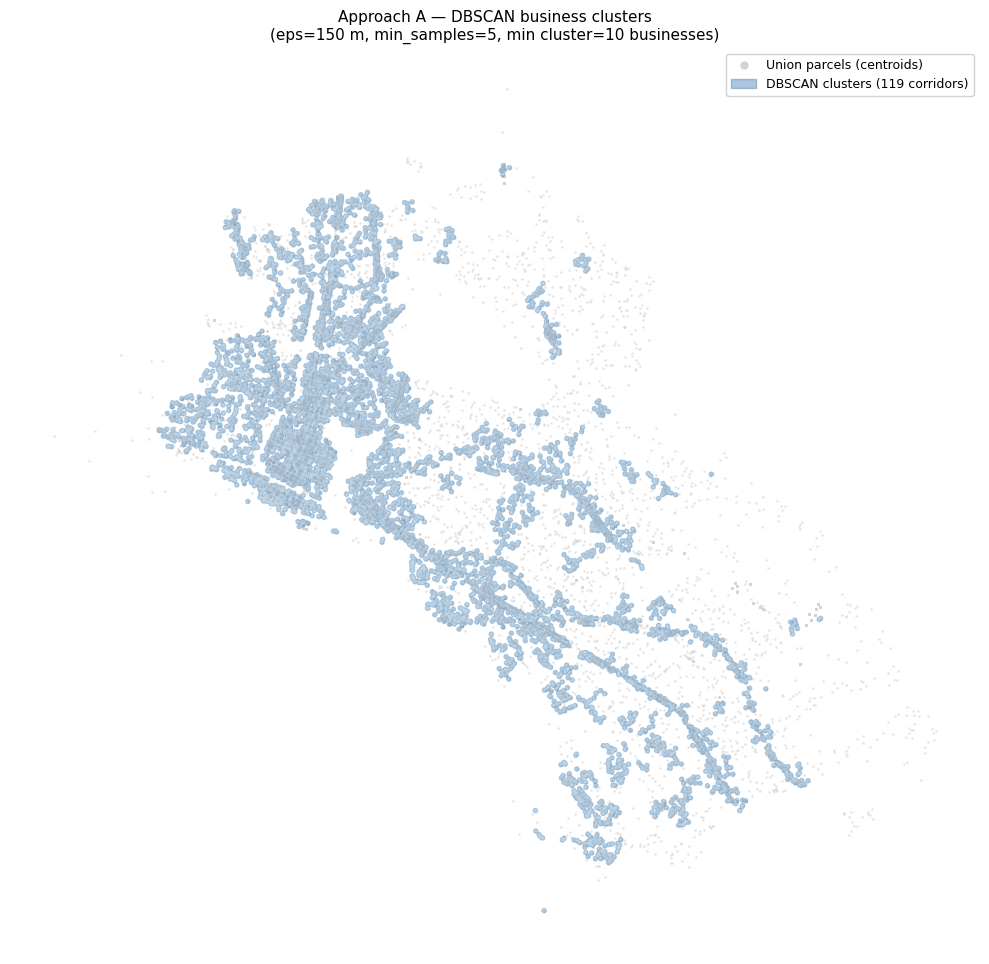

In [16]:

# ── Map: DBSCAN candidate corridors ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

union_centroids.plot(ax=ax, color="lightgrey", markersize=1, alpha=0.4)

dbscan_corridors.plot(ax=ax, facecolor="steelblue", alpha=0.35,
                      edgecolor="steelblue", linewidth=0.8)

legend_handles = [
    mlines.Line2D([], [], color="lightgrey", marker="o", linestyle="None",
                  markersize=5, label="Union parcels (centroids)"),
    mpatches.Patch(facecolor="steelblue", alpha=0.45, edgecolor="steelblue",
                   label=f"DBSCAN clusters ({len(dbscan_corridors)} corridors)"),
]

ax.set_title(f"Approach A — DBSCAN business clusters\n"
             f"(eps={DBSCAN_EPS_M} m, min_samples={DBSCAN_MIN_SAMPLES}, "
             f"min cluster={DBSCAN_MIN_CLUSTER_N} businesses)", fontsize=11)
ax.legend(handles=legend_handles, loc="upper right", fontsize=9, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()
plt.show()



### Approach A — Assessment

A global DBSCAN run across Oakland works well for detecting locally dense business nodes.
The fundamental challenge is not stratification but the **mega-cluster problem**: the
contiguous commercial fabric of the Oakland flatlands (downtown through Fruitvale) tends to
merge into one or a small number of very large clusters at any `eps` scale practical for
smaller nodes elsewhere in the city.

| | |
|---|---|
| ✅ **Locally data-driven** | Clusters reflect genuine co-location of businesses, not arbitrary boundaries |
| ✅ **Detects density, not just presence** | Isolated businesses don't become corridors; proximity is required |
| ✅ **Shape follows street patterns** | The buffered-union footprint conforms naturally to block structure |
| ⚠️ **Mega-cluster problem** | The dense flatlands tend to merge into one giant cluster that isn't a single corridor |
| ⚠️ **Parameter sensitivity** | `eps` and `min_samples` require careful tuning; small changes can collapse or split clusters |
| ⚠️ **No sense of identity** | Clusters with similar density profiles are geometrically interchangeable — community character is invisible |



## 3.2 Approach B — Grid-Density Thresholding

**Idea:** Overlay a regular square grid and count businesses per cell.  Within Oakland, a
simple **global absolute threshold** is appropriate — the city is compact enough that a
per-cell business count is a fair comparison across all neighbourhoods.  No sub-region
normalisation is needed.

A cell is "active" if its business count meets or exceeds `GRID_BIZ_THRESHOLD`.  Adjacent
active cells are dissolved into blobs; blobs below `GRID_MIN_CELLS` are dropped as isolated
spikes.

**Parameters:**

| Parameter | Value | Meaning |
|---|---|---|
| Cell size | 250 m | Spatial resolution of the grid |
| Absolute threshold | ≥ 5 businesses/cell | Minimum count for a cell to be considered active |
| Min cells per blob | 2 | Discard single-cell isolated spikes |


In [17]:

# ── Build fishnet grid over Oakland parcel extent ─────────────────────────────
# Within Oakland, a simple absolute threshold is appropriate — the city is
# compact enough that a global per-cell count is a fair comparison everywhere.
minx, miny, maxx, maxy = parcels_union.total_bounds
cs    = GRID_CELL_SIZE_M

xs    = np.arange(minx, maxx + cs, cs)
ys    = np.arange(miny, maxy + cs, cs)
cells = [box(x, y, x + cs, y + cs) for x in xs for y in ys]

grid = gpd.GeoDataFrame({"cell_id": range(len(cells))}, geometry=cells, crs=PARCEL_CRS)

# ── Count businesses per cell ─────────────────────────────────────────────────
biz_in_cells = gpd.sjoin(businesses_gdf[["geometry"]], grid, how="inner", predicate="within")
cell_counts  = biz_in_cells.groupby("cell_id").size().rename("biz_count")
grid = grid.merge(cell_counts, on="cell_id", how="left").fillna({"biz_count": 0})
grid["biz_count"] = grid["biz_count"].astype(int)

# ── Global absolute threshold ─────────────────────────────────────────────────
active = grid[grid["biz_count"] >= GRID_BIZ_THRESHOLD].copy()

print(f"Grid cells (total)                     : {len(grid):,}")
print(f"Active cells (≥{GRID_BIZ_THRESHOLD} businesses/cell)         : {len(active):,}")

# ── Dissolve neighbours into blobs, filter small ones ────────────────────────
active_dissolved = (
    active.dissolve()
    .explode(index_parts=False)
    .reset_index(drop=True)
    .rename_axis("blob_id")
    .reset_index()
)

cell_centroids   = active.copy()
cell_centroids["geometry"] = active.geometry.centroid
blob_cell_counts = gpd.sjoin(
    cell_centroids[["geometry"]],
    active_dissolved[["blob_id", "geometry"]],
    how="inner", predicate="within",
).groupby("blob_id").size().rename("n_cells")

active_dissolved = active_dissolved.merge(blob_cell_counts, on="blob_id", how="left").fillna(0)
active_dissolved["n_cells"] = active_dissolved["n_cells"].astype(int)
grid_corridors = active_dissolved[active_dissolved["n_cells"] >= GRID_MIN_CELLS].copy()

print(f"\nDissolved blobs                        : {len(active_dissolved)}")
print(f"Blobs after min-cell filter            : {len(grid_corridors)}")
print(f"\nBlob sizes (cells):")
print(grid_corridors["n_cells"].describe().round(1))


Grid cells (total)                     : 9,114
Active cells (≥5 businesses/cell)         : 895

Dissolved blobs                        : 143
Blobs after min-cell filter            : 40

Blob sizes (cells):
count     40.0
mean      19.8
std       86.5
min        2.0
25%        2.0
50%        4.5
75%        8.0
max      552.0
Name: n_cells, dtype: float64


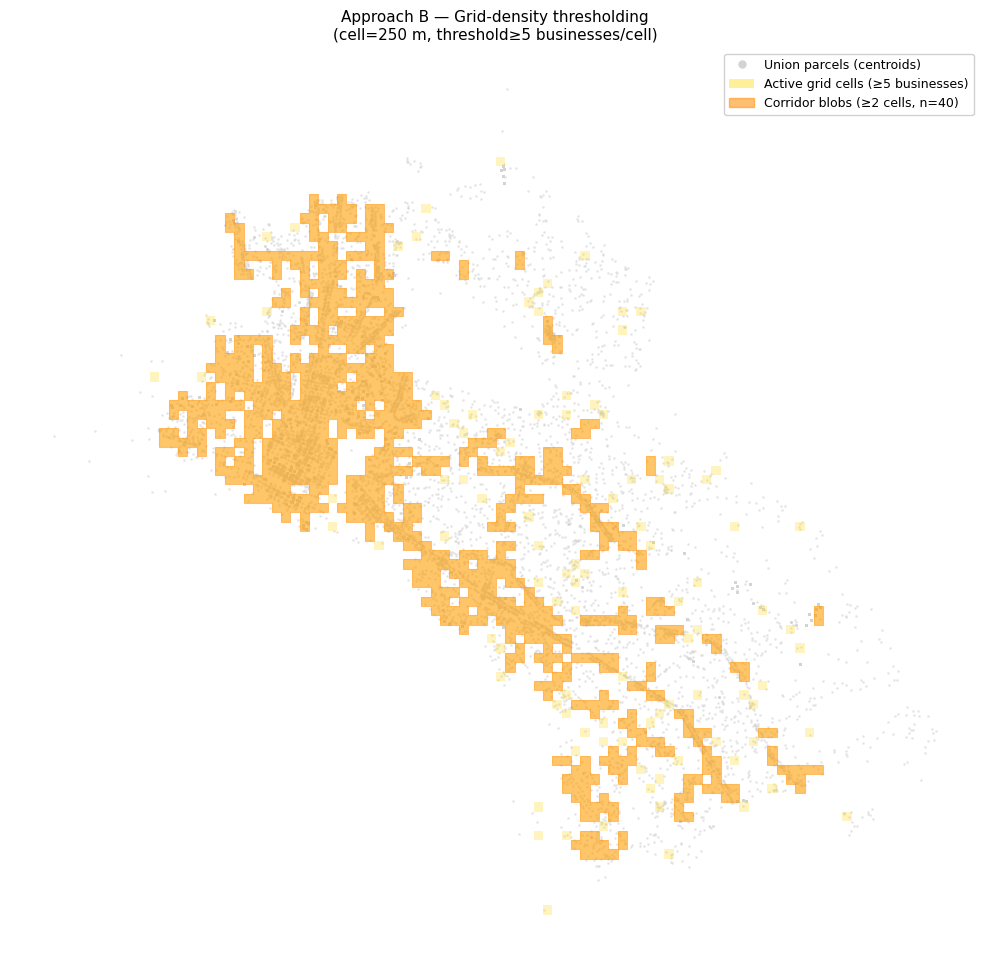

In [18]:

# ── Map: grid-density candidate corridors ────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

union_centroids.plot(ax=ax, color="lightgrey", markersize=1, alpha=0.4)

# Show all active cells lightly for context
active.plot(ax=ax, facecolor="gold", alpha=0.25, edgecolor="none")

# Corridor blobs (multi-cell) with stronger fill
grid_corridors.plot(ax=ax, facecolor="darkorange", alpha=0.45,
                    edgecolor="darkorange", linewidth=0.8)

legend_handles = [
    mlines.Line2D([], [], color="lightgrey", marker="o", linestyle="None",
                  markersize=5, label="Union parcels (centroids)"),
    mpatches.Patch(facecolor="gold", alpha=0.4, edgecolor="none",
                   label=f"Active grid cells (≥{GRID_BIZ_THRESHOLD} businesses)"),
    mpatches.Patch(facecolor="darkorange", alpha=0.55, edgecolor="darkorange",
                   label=f"Corridor blobs (≥{GRID_MIN_CELLS} cells, n={len(grid_corridors)})"),
]

ax.set_title(f"Approach B — Grid-density thresholding\n"
             f"(cell={GRID_CELL_SIZE_M} m, threshold≥{GRID_BIZ_THRESHOLD} businesses/cell)", fontsize=11)
ax.legend(handles=legend_handles, loc="upper right", fontsize=9, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()
plt.show()



### Approach B — Assessment

| | |
|---|---|
| ✅ **Highly transparent** | A cell is "active" or not based on a single, legible threshold — easy to explain and audit |
| ✅ **Scale-adjustable** | Changing cell size shifts between fine-grained block-level and coarser neighbourhood-level results |
| ✅ **Stable to business turnover** | Adding/removing a handful of businesses rarely flips a cell's status |
| ⚠️ **Grid alignment is arbitrary** | Shifting the grid origin by 50 m can redraw corridor boundaries substantially (the "MAUP") |
| ⚠️ **Rectangular blobs** | Grid cells produce boxy corridor shapes that rarely match the organic form of a commercial street |
| ⚠️ **Misses linear corridors** | A long commercial strip with moderate density can fall below per-cell thresholds even though it functions as a coherent corridor |
| ⚠️ **Business count only** | Like Approach A, this knows nothing about parcel use, property type, or community identity |



## 3.3 Approach C — Parcel-Connectivity Blobs with Spatial-Diversity Selection

**Idea:** Start from the *union parcel set* — parcels that are either commercially zoned or
contain a business.  A small buffer bridges narrow gaps across streets and alleys; dissolving
produces connected "blobs" of commercial land.  Islands below `BLOB_MIN_PARCELS` are pruned.

This method naturally produces **well-distributed results** across Oakland because commercial
land traces the city's historic street grid regardless of current business density.  The
challenge is the opposite: it yields more blobs than needed.

The addition here is a **greedy spatial-diversity selection** step.  Each blob is scored by a
combination of parcel count and business density.  Starting from the highest-scoring blob, the
algorithm iteratively adds the next best candidate only if its centroid is at least
`MIN_SPACING_M` away from all already-selected corridors.  This produces ~`TARGET_CORRIDORS`
selections that are both high-quality *and* geographically spread across Oakland.

**Parameters:**

| Parameter | Value | Meaning |
|---|---|---|
| Connect buffer | 40 m | Gap-closing distance between adjacent parcels |
| Min parcels per blob | 10 | Discard tiny isolated commercial lots |
| Target corridors | 15 | Number of corridors to select within Oakland |
| Min spacing | 1,000 m | Minimum centroid-to-centroid distance between selections |


In [19]:

# ── Buffer → dissolve → explode into individual connected blobs ───────────────
buffered  = parcels_union.geometry.buffer(PARCEL_CONNECT_BUF_M)
dissolved = unary_union(buffered)

parcel_blobs = (
    gpd.GeoDataFrame(geometry=[dissolved], crs=PARCEL_CRS)
    .explode(index_parts=False)
    .reset_index(drop=True)
    .rename_axis("blob_id")
    .reset_index()
)

# ── Count union parcels per blob ──────────────────────────────────────────────
blob_join = gpd.sjoin(
    union_centroids[["geometry"]],
    parcel_blobs[["blob_id", "geometry"]],
    how="inner", predicate="within",
)
blob_parcel_counts = blob_join.groupby("blob_id").size().rename("parcel_count")
parcel_blobs = parcel_blobs.merge(blob_parcel_counts, on="blob_id", how="left").fillna(0)
parcel_blobs["parcel_count"] = parcel_blobs["parcel_count"].astype(int)

# ── Count businesses per blob ─────────────────────────────────────────────────
biz_join = gpd.sjoin(
    businesses_gdf[["geometry"]],
    parcel_blobs[["blob_id", "geometry"]],
    how="inner", predicate="within",
)
blob_biz_counts = biz_join.groupby("blob_id").size().rename("biz_count")
parcel_blobs = parcel_blobs.merge(blob_biz_counts, on="blob_id", how="left").fillna(0)
parcel_blobs["biz_count"] = parcel_blobs["biz_count"].astype(int)

# ── Negative-buffer to remove artificial expansion, then filter ───────────────
parcel_blobs["geometry"] = parcel_blobs.geometry.buffer(-PARCEL_CONNECT_BUF_M)
connectivity_corridors = parcel_blobs[parcel_blobs["parcel_count"] >= BLOB_MIN_PARCELS].copy()

# ── Score each blob: balance parcel count and business density ────────────────
connectivity_corridors = connectivity_corridors.copy()
connectivity_corridors["biz_density"] = (
    connectivity_corridors["biz_count"] / connectivity_corridors["parcel_count"].clip(lower=1)
)
connectivity_corridors["score"] = (
    np.log(connectivity_corridors["parcel_count"]) +
    np.log1p(connectivity_corridors["biz_count"])
)

# ── Greedy spatial-diversity selection ───────────────────────────────────────
# Iterates through blobs in score order; selects each only if its centroid is
# at least MIN_SPACING_M from all already-selected corridor centroids.
candidates        = connectivity_corridors.sort_values("score", ascending=False).copy()
cand_centroids    = candidates.geometry.centroid
selected_idx      = []
selected_cents    = []

for idx, row in candidates.iterrows():
    c = cand_centroids[idx]
    if all(c.distance(s) >= MIN_SPACING_M for s in selected_cents):
        selected_idx.append(idx)
        selected_cents.append(c)
    if len(selected_idx) >= TARGET_CORRIDORS:
        break

selected_corridors = connectivity_corridors.loc[selected_idx].copy()

print(f"Total blobs after dissolve            : {len(parcel_blobs):,}")
print(f"Blobs ≥ {BLOB_MIN_PARCELS} parcels (candidates)  : {len(connectivity_corridors)}")
print(f"Selected corridors (spatial spread)   : {len(selected_corridors)}")
print(f"\nSelected corridor stats:")
print(selected_corridors[["parcel_count", "biz_count", "biz_density"]].describe().round(1))


Total blobs after dissolve            : 1,069
Blobs ≥ 10 parcels (candidates)  : 78
Selected corridors (spatial spread)   : 15

Selected corridor stats:
       parcel_count  biz_count  biz_density
count          15.0       15.0         15.0
mean          963.4     1659.6          4.1
std          2494.3     4539.2          7.2
min            25.0       53.0          0.3
25%            98.0      202.0          1.0
50%           137.0      287.0          1.9
75%           323.5      841.0          4.1
max          9815.0    18010.0         29.4


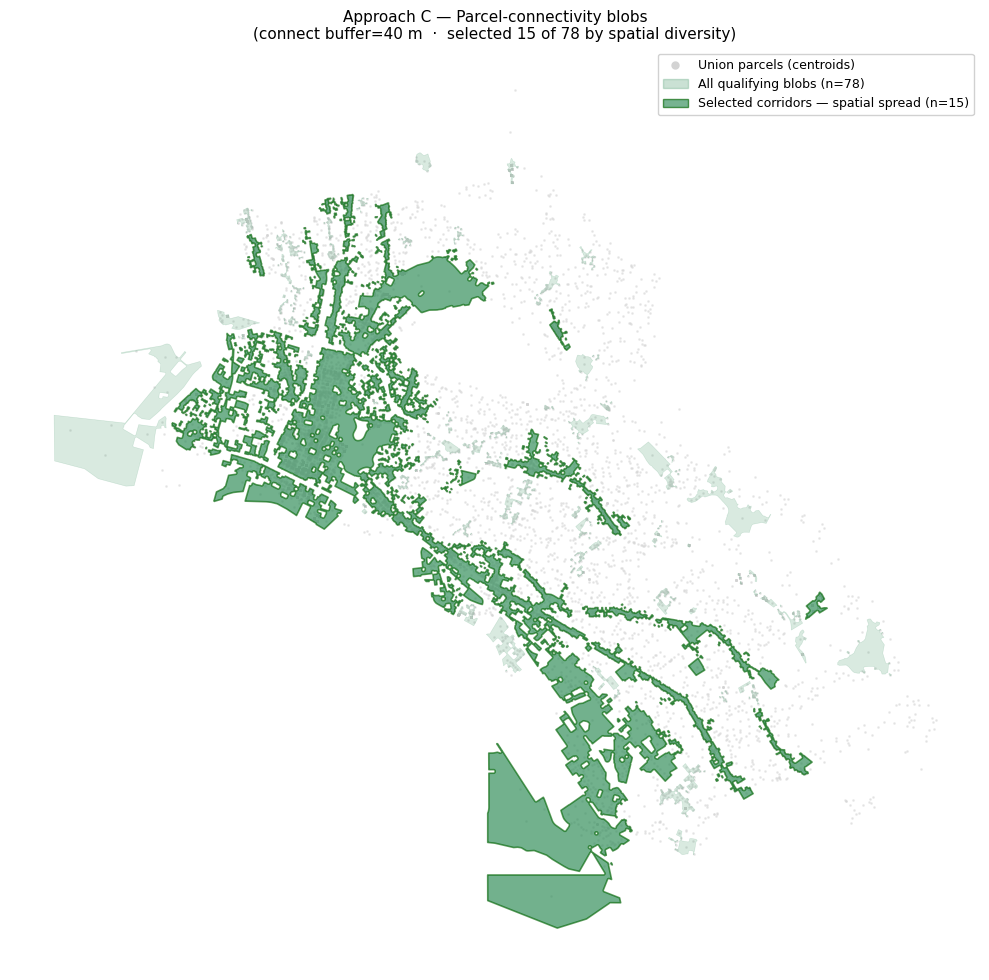

In [20]:

# ── Map: parcel-connectivity candidate corridors ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 10))

union_centroids.plot(ax=ax, color="lightgrey", markersize=1, alpha=0.4)

# All qualifying blobs in light green for context
connectivity_corridors.plot(ax=ax, facecolor="seagreen", alpha=0.18,
                            edgecolor="seagreen", linewidth=0.4)

# Selected ~25 with stronger fill and darker outline
selected_corridors.plot(ax=ax, facecolor="seagreen", alpha=0.60,
                        edgecolor="darkgreen", linewidth=1.2)

legend_handles = [
    mlines.Line2D([], [], color="lightgrey", marker="o", linestyle="None",
                  markersize=5, label="Union parcels (centroids)"),
    mpatches.Patch(facecolor="seagreen", alpha=0.25, edgecolor="seagreen",
                   label=f"All qualifying blobs (n={len(connectivity_corridors)})"),
    mpatches.Patch(facecolor="seagreen", alpha=0.65, edgecolor="darkgreen",
                   label=f"Selected corridors — spatial spread (n={len(selected_corridors)})"),
]

ax.set_title(f"Approach C — Parcel-connectivity blobs\n"
             f"(connect buffer={PARCEL_CONNECT_BUF_M} m  ·  "
             f"selected {len(selected_corridors)} of {len(connectivity_corridors)} by spatial diversity)",
             fontsize=11)
ax.legend(handles=legend_handles, loc="upper right", fontsize=9, framealpha=0.9)
ax.set_axis_off()
plt.tight_layout()
plt.show()



### Approach C — Assessment

| | |
|---|---|
| ✅ **Grounded in land use** | Corridors reflect what land is *zoned or used* for, not just where a business currently operates |
| ✅ **Stable to business churn** | A vacated storefront doesn't remove its parcel from the corridor |
| ✅ **Naturally street-aligned** | Parcels front onto streets, so blobs tend to trace commercial thoroughfares rather than produce round blobs |
| ✅ **Combines two signals** | Both land-use codes and actual business occupancy feed the parcel filter (union set) |
| ⚠️ **Buffer distance is critical** | Too small: fragmented corridors split across a street. Too large: whole neighbourhoods merge |
| ⚠️ **Large blobs are hard to split** | Dense downtown areas may dissolve into one giant blob that isn't a single corridor |
| ⚠️ **No sense of corridor intensity** | A blob with 30 parcels looks the same as one with 300 — intensity must be added separately |



## 3.4 Side-by-Side Comparison Map

All three sets of candidate corridors shown together alongside the existing BID boundaries,
to give a quick visual read on where they agree and where they diverge.


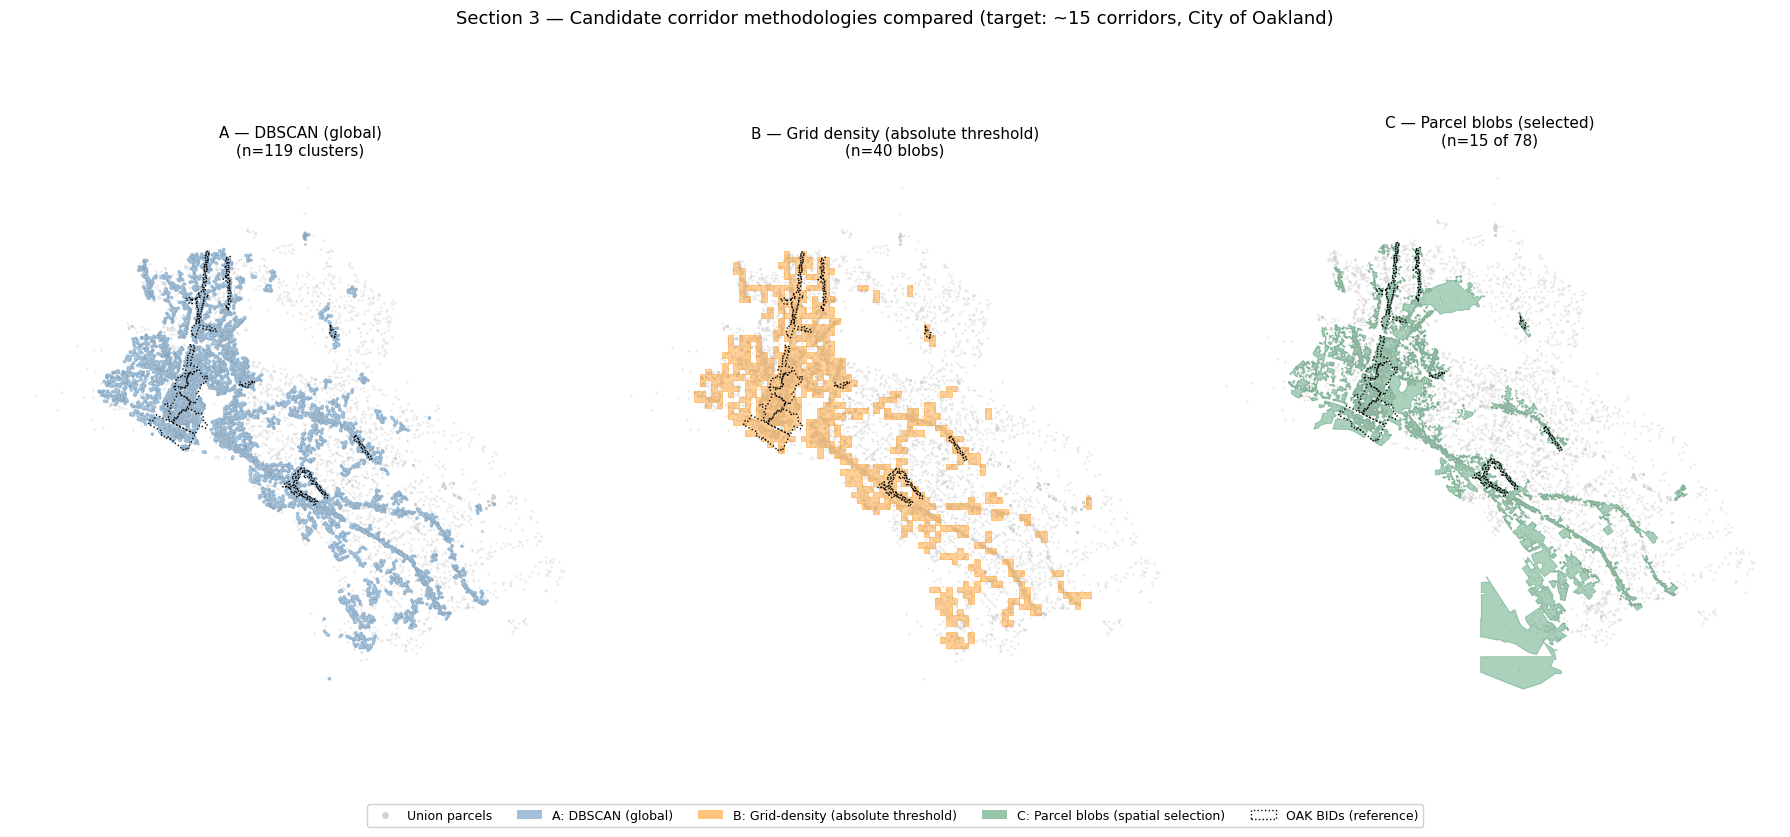

In [21]:

fig, axes = plt.subplots(1, 3, figsize=(18, 8))

configs = [
    (axes[0], dbscan_corridors,    "steelblue",
     f"A — DBSCAN (global)\n(n={len(dbscan_corridors)} clusters)"),
    (axes[1], grid_corridors,      "darkorange",
     f"B — Grid density (absolute threshold)\n(n={len(grid_corridors)} blobs)"),
    (axes[2], selected_corridors,  "seagreen",
     f"C — Parcel blobs (selected)\n(n={len(selected_corridors)} of {len(connectivity_corridors)})"),
]

for ax, corridors, colour, title in configs:
    union_centroids.plot(ax=ax, color="lightgrey", markersize=0.8, alpha=0.35)
    corridors.plot(ax=ax, facecolor=colour, alpha=0.40, edgecolor=colour, linewidth=0.7)
    # OAK BIDs for reference in each panel
    oak_bids.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=1.0, linestyle=":")
    ax.set_title(title, fontsize=11)
    ax.set_axis_off()

# Shared legend
shared_handles = [
    mlines.Line2D([], [], color="lightgrey", marker="o", linestyle="None",
                  markersize=4, label="Union parcels"),
    mpatches.Patch(facecolor="steelblue",  alpha=0.5, label="A: DBSCAN (global)"),
    mpatches.Patch(facecolor="darkorange", alpha=0.5, label="B: Grid-density (absolute threshold)"),
    mpatches.Patch(facecolor="seagreen",   alpha=0.5, label="C: Parcel blobs (spatial selection)"),
    mpatches.Patch(facecolor="none", edgecolor="black", linewidth=1.0,
                   linestyle=":", label="OAK BIDs (reference)"),
]
fig.legend(handles=shared_handles, loc="lower center", ncol=5, fontsize=9,
           framealpha=0.9, bbox_to_anchor=(0.5, -0.02))

fig.suptitle("Section 3 — Candidate corridor methodologies compared (target: ~15 corridors, City of Oakland)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()



## 3.5 Observations & Recommended Path Forward

### What the three approaches tell us about Oakland

All three approaches operate on the same Oakland-clipped parcel and business data.
They offer complementary views of where corridors concentrate:

* **DBSCAN** detects commercially active clusters defined by proximity of businesses.
  It is best at identifying *where businesses actually concentrate* at a local level, but
  corridor shapes are volatile and sensitive to the `eps` parameter.  The dense Oakland
  flatlands (downtown through Fruitvale) tend to produce one or a few large clusters that
  absorb what should be distinct corridors — this is the primary limitation within Oakland.

* **Grid density** surfaces the *busiest cells* against a consistent absolute threshold.
  Within Oakland, a global threshold is fair because commercial density does not vary as
  dramatically as it would across the broader East Bay.  The limitation remains the grid's
  rectangular geometry and arbitrary origin — a commercial strip straddling a cell boundary
  can be artificially split.

* **Parcel connectivity + spatial selection** provides the most actionable output.
  The full blob layer already traces commercial land across Oakland; the greedy selection
  produces ~15 corridors that are both high-quality (scored by parcel count and business
  density) and geographically spread (enforced minimum spacing of 1 km).  This is the
  closest of the three to a working first draft of Oakland corridor boundaries.

### Key tensions to resolve

1. **Scale vs. granularity** — A 1 km minimum spacing may skip a legitimate secondary
   corridor adjacent to a major one (e.g. two parallel commercial streets in East Oakland).
   This parameter should be discussed with the team.

2. **Density vs. land use** — Approaches A and B measure *current business activity*;
   Approach C measures *commercial land structure*.  A corridor with many parcels but few
   active businesses may be declining or transitional — worth distinguishing, not ignoring.

3. **The downtown problem is structural** — Even with spatial selection, downtown Oakland
   and the central flatlands contain the most commercial land and businesses.  Any
   purely data-driven method will weight these areas heavily.  A community input step will
   be needed to ensure that smaller, community-anchored corridors are not underrepresented.

### Recommended next step

Use **Approach C's selected corridors** as the working spatial skeleton for the next
discussion.  For each selected corridor blob, bring in:
- Business count and industry mix (from DataAxle) → *economic character*
- Parcel use-code breakdown → *land-use character*
- Proximity to existing BIDs or Policy Polygons → *alignment with established boundaries*

This profile will allow the team to evaluate whether each blob feels like a coherent
corridor, where blobs should be split or merged, and which areas of Oakland are currently
underrepresented.
